# **Proyecto de Machine Learning: nomadismo digital y coste de vida global**

**Enfoque estratégico:** Clustering de ciudades como destino nómada digital & Regresión para predecir el score nómada de países en función de las variables.

**Autores:** Daniela Aguirre, Agustín Arganín y Juan F. Cía

**Base del proyecto:** [EDA Nomadismo Digital](https://github.com/juanfcia/EDA-Nomadismo-Digital)

**Datasets y registros:**
1. **Registros:** 4,742 ciudades y 85 países.
2. **Datasets:** [Variables agregadas](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/cost-of-living-variables-agregadas.csv), [Mapa de variables](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/cost-of-living-vars-map.csv), [Digital Nomad Index Circleloop](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/digital-nomad-index-cicleloop-clean.csv) y [Digital Nomad Index Movingto](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/digital-nomad-index-movingto-clean.csv).
3. **Hipótesis validadas en el proyecto del EDA:** 9 hipótesis validadas

## **Machine Learning**

### **Contexto**
El nomadismo digital es un fenómeno creciente: profesionales que trabajan en remoto desde cualquier lugar del mundo. Elegir destino implica evaluar decenas de factores — coste de vida, conectividad, seguridad, calidad de vida — que interactúan de forma no lineal.

### **Preguntas de negocio**
1. ¿Qué factores de coste de vida, conectividad y bienestar determinan el atractivo de un destino para nómadas digitales?
2. ¿Podemos segmentar las ciudades del mundo en perfiles nómadas y predecir el score de un país?*

### **Hallazgos del EDA que motivan este proyecto**
| Hallazgo | Estadístico | Implicación ML |
|---|---|---|
| **Conectividad** = predictor #1 del score nómada | r=0.73, p<0.001 | Feature de alta importancia |
| **Bienestar social** correlaciona fuertemente | r=0.70, p<0.001 | Feature de alta importancia |O
| **Los mejores destinos son más caros** | Top 20% coste mayor | Relación no lineal con el score |
| **Alimentación** pesa más que vivienda | Hipótesis rechada | Validar con feature importance |
| **Seguridad no tiene correlación fuerte** | r=0.18, p>0.05 | Variable de baja importancia |
| **Outliers value for money** identificados | Bajo coste + alto score | ¿Forman un clúster propio? |

### **Enfoque estratético del proyecto**
Pipeline híbrido en 3 fases:

1. **Fase 1 — Clustering (aprendizaje no supervisado):** Segmentar 4,742 ciudades en perfiles nómadas usando 7 índices de coste de vida.
2. **Fase 2 — Regresión (aprendizaje supervisado):** Predecir el `digital_nomad_score` de 81 países usando indicadores de coste, conectividad, bienestar y los perfiles de cluster descubiertos en la fase 1.
3. **Fase 3 - Iteación añadiendo nuevos datos y ver variabilidad predictora:** Incluir datos de series temporales sobre inflación, ingresos por turismo, precio de la vivienda, clima... y analizar si los modelos baseline de fases 1 y 2 modifican su comportamiento para negocio.

### Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn - Preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import cross_validate, train_test_split, \
									GridSearchCV, KFold, RandomizedSearchCV

from sklearn.metrics import r2_score, root_mean_squared_error

# Sklearn - Regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Guardado del modelo
import joblib

import warnings
warnings.filterwarnings("ignore")

`Google Colab`

In [4]:
from google.colab import drive
drive.mount("/content/drive")


path = "/content/drive/MyDrive/Colab Notebooks/The Bridge/projectML"

# Carga de datasets limpios del EDA
df_cities = pd.read_csv(f"{path}/cost-of-living-variables-agregadas.csv")
df_circleloop = pd.read_csv(f"{path}/digital-nomad-index-cicleloop-clean.csv")
df_movingto = pd.read_csv(f"{path}/digital-nomad-index-movingto-clean.csv")

Mounted at /content/drive


In [2]:
# Carga de datasets limpios del EDA

df_cities = pd.read_csv("../data_sample/cost-of-living-variables-agregadas.csv")
df_circleloop = pd.read_csv("../data_sample/digital-nomad-index-cicleloop-clean.csv")
df_movingto = pd.read_csv("../data_sample/digital-nomad-index-movingto-clean.csv")

### Aproximación: Mini vistazo de los dataset y distribuciones más relevantes

In [3]:
# Número de registros y variables por cada uno de los datasets

print(f"Dataset 1: Cost of Living -> {df_cities.shape[0]} ciudades y {df_cities.shape[1]} variables")
print(f"Dataset 2: Circleloop -> {df_circleloop.shape[0]} países y {df_circleloop.shape[1]} variables")
print(f"Dataset 3: Movingto -> {df_movingto.shape[0]} países y {df_movingto.shape[1]} variables")

Dataset 1: Cost of Living -> 4742 ciudades y 65 variables
Dataset 2: Circleloop -> 85 países y 10 variables
Dataset 3: Movingto -> 40 países y 10 variables


In [4]:
# Imprimimos los tres datasets seguidos para echarle un vistazo

print("Dataset 1: Cost of Living -> 4742 ciudades y 65 variables")
display(df_cities.head(10))

print("Dataset 2: Circleloop -> 85 países y 10 variables")
display(df_circleloop.head(10))

print("Dataset 3: Movingto -> 40 países y 10 variables")
display(df_movingto.head(10))

Dataset 1: Cost of Living -> 4742 ciudades y 65 variables


,city_name,country_name,meal_inexpensive_restaurant,meal_midrange_restaurant_2p,mcmeal_fastfood,beer_domestic_restaurant_0_5l,beer_imported_restaurant_0_33l,cappuccino_restaurant,soda_restaurant_0_33l,water_restaurant_0_33l,...,mortgage_interest_rate_20y,data_quality_flag,continent,nomad_housing_cost,basic_basket_index,daily_meal_cost,monthly_nomad_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
0,Seoul,South Korea,7.68,53.78,6.15,3.07,4.99,3.93,1.48,0.79,...,3.47,1,Asia,650.030,4.631667,11.61,1209.990,2.222845,37.934560,24.168098
1,Shanghai,China,5.69,39.86,5.69,1.14,4.27,3.98,0.53,0.33,...,5.03,1,Asia,830.905,1.995000,9.67,1147.345,1.237527,38.445808,58.519794
2,Guangzhou,China,4.13,28.47,4.98,0.85,1.71,3.54,0.44,0.33,...,5.19,1,Asia,425.365,1.572500,7.67,692.370,1.750047,33.946830,35.105391
3,Mumbai,India,3.68,18.42,3.68,2.46,4.30,2.48,0.48,0.19,...,7.96,1,Asia,408.225,1.078333,6.16,590.785,1.084675,23.108384,63.704530
4,Delhi,India,4.91,22.11,4.30,1.84,3.68,1.77,0.49,0.19,...,8.06,1,Asia,182.575,1.047500,6.68,391.890,1.496491,15.848671,31.131705
5,Dhaka,Bangladesh,1.95,11.71,4.88,5.85,5.12,1.95,0.29,0.16,...,9.26,1,Asia,114.940,1.193333,3.90,286.730,0.979074,17.689162,40.943255
6,Osaka,Japan,7.45,48.39,5.36,3.35,3.72,3.28,1.09,0.81,...,1.49,1,Asia,525.550,3.302500,10.73,1035.305,2.243262,31.288344,22.629023
7,Jakarta,Indonesia,2.59,22.69,3.57,2.06,3.24,2.23,0.61,0.27,...,9.05,1,Asia,391.510,1.765000,4.82,643.550,0.791112,20.552147,76.899356
8,Shenzhen,China,4.27,28.47,4.98,1.14,3.99,4.20,0.47,0.34,...,4.99,1,Asia,586.910,1.829167,8.47,890.265,1.766013,40.695297,37.330017
9,Kinshasa,Congo,15.11,42.63,10.08,1.74,2.50,4.35,2.78,0.84,...,19.33,0,Africa,1362.500,4.215000,19.46,2664.840,0.150103,42.229039,340.625000


Dataset 2: Circleloop -> 85 países y 10 variables


,rank,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49
5,6,France,177.93,50.45,32.84,833.8,6.66,12.8,5360,60.80
6,7,Netherlands,125.82,88.13,50.11,1334.3,7.45,13.4,3440,60.27
7,8,Australia,58.52,88.35,57.11,1262.8,7.22,30.0,17600,60.16
8,9,Switzerland,186.40,73.85,85.15,1699.5,7.56,29.9,3840,60.15
9,10,Germany,120.13,49.67,33.95,906.4,7.08,15.7,12720,60.00


Dataset 3: Movingto -> 40 países y 10 variables


,rank,country,overall_score,internet_speed,cost_of_living,safety,visa_ease,quality_of_life,taxes,tax_free_period
0,1,Portugal,92,90,85,95,95,95,NHR 20%,10 years
1,2,Estonia,91,95,75,90,98,92,0-20%,183 days/year
2,3,Georgia,90,85,88,82,100,80,1%,183 days/year
3,4,Spain,89,88,80,92,92,94,24%,183 days/year
4,5,Thailand,88,85,95,80,90,88,0-35%,183 days/year
5,6,Mexico,87,82,90,75,94,86,1.92-35%,183 days/year
6,7,Czech Republic,86,87,78,88,85,90,15%,183 days/year
7,8,Malaysia,85,80,92,85,90,85,0-30%,182 days/year
8,9,Croatia,84,84,76,88,88,89,24%,1 year
9,10,Costa Rica,83,79,85,80,90,88,0-25%,183 days/year


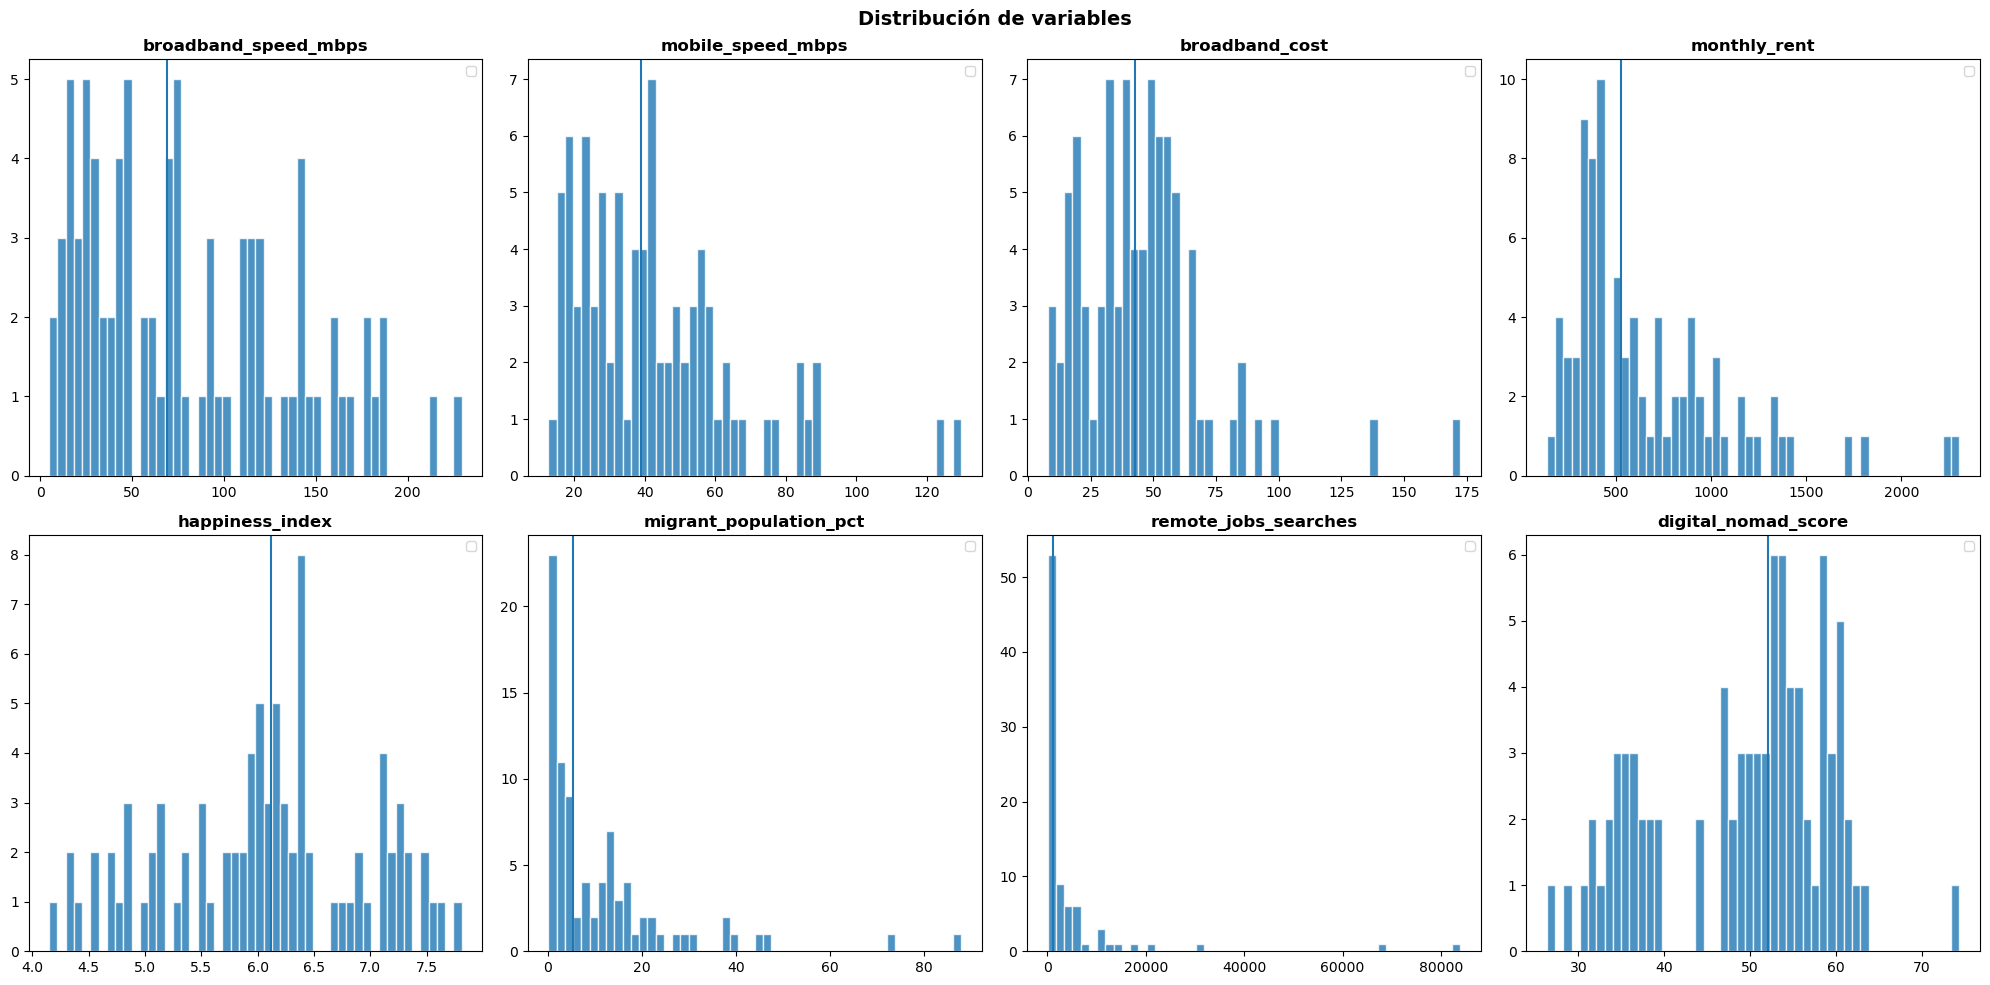

In [ ]:
# Distribuciones de las features de clustering
nom_features = df_circleloop.iloc[:, 2:10].columns


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(nom_features):
	axes[i].hist(df_circleloop[col], bins=50, edgecolor="white", alpha=0.8)
	axes[i].set_title(col, fontweight="bold")
	axes[i].axvline(df_circleloop[col].median())
	axes[i].legend(fontsize=9)

fig.suptitle(
	"Distribución de variables",
	fontsize=14,
	fontweight="bold"
)
plt.tight_layout()
plt.show()

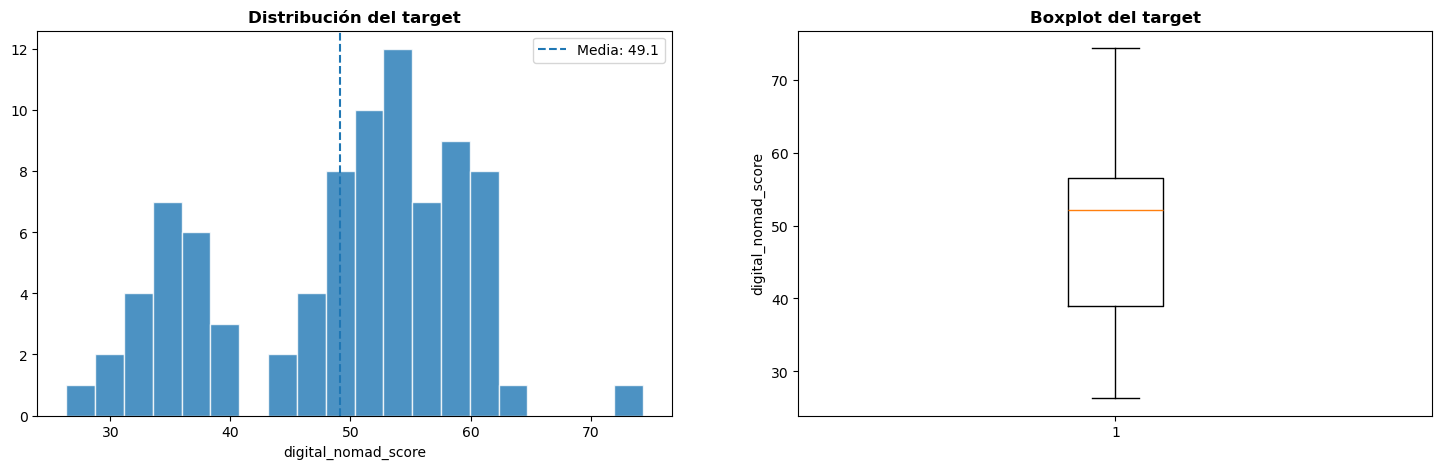

In [ ]:
# Análisis del target: digital_nomad_score

target = "digital_nomad_score"

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
# Distribución con histograma
axs[0].hist(
	df_circleloop[target],
	bins=20,
	edgecolor="white",
	alpha=0.8
)
axs[0].axvline(
	df_circleloop[target].mean(),
	linestyle="--",
	label=f"Media: {df_circleloop[target].mean():.1f}"
)
axs[0].set_title("Distribución del target", fontweight="bold")
axs[0].set_xlabel(target)
axs[0].legend()

# Boxplot para ver estadíticos y outliers

axs[1].boxplot(df_circleloop[target], vert=True)
axs[1].set_title("Boxplot del target", fontweight="bold")
axs[1].set_ylabel(target)
plt.show()

#### Correlaciones

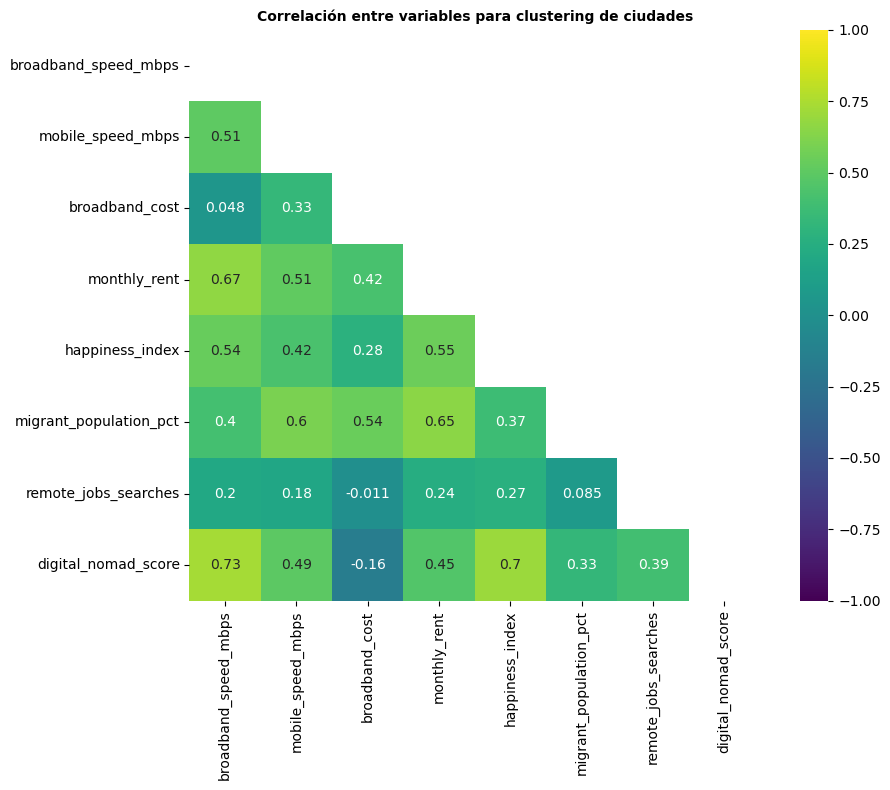

In [ ]:
# Correlación entre features para clustering de ciudades

correlations = df_circleloop[nom_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(correlations))
sns.heatmap(
	correlations,
	mask=mask,
	annot=True,
	cmap="viridis",
	center=0,
	vmax=1,
	vmin=-1,
	square=True,
	ax=ax)
ax.set_title(
	"Correlación entre variables para clustering de ciudades",
	fontsize=10,
	fontweight="bold"
)
plt.tight_layout()
plt.show()

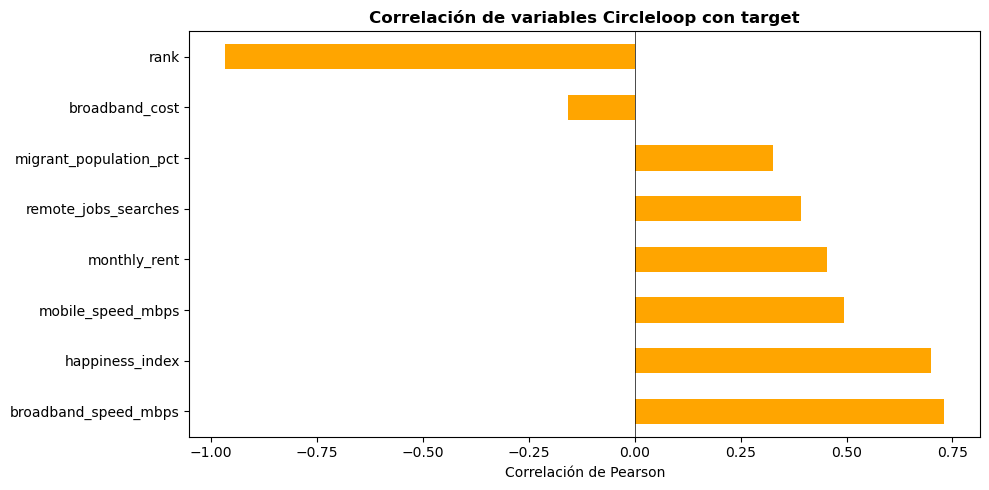

In [ ]:
# Correlaciones de variables Circleloop con el target

corr_target = df_circleloop.select_dtypes(include="number").corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corr_target.plot(kind="barh", ax=ax, color="orange", edgecolor="none")
ax.set_title("Correlación de variables Circleloop con target", fontweight="bold")
ax.set_xlabel("Correlación de Pearson")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Preprocessing

In [4]:
# Agregar Cost of Living a nivel país (media de todas las ciudades)

num_cols = df_cities.select_dtypes(include="number").columns.tolist()
df_countries = df_cities.groupby("country_name")[num_cols].mean().reset_index()

In [ ]:
# Añadir continente (moda por país)

country_continent = df_cities.groupby("country_name")["continent"].first().reset_index()
df_countries = df_countries.merge(country_continent, on="country_name")

In [ ]:
# Añadir número de ciudades por país

city_count = df_cities.groupby("country_name").size().reset_index(name="city_count")
df_countries = df_countries.merge(city_count, on="country_name")

In [ ]:
# Merge con Circleloop (inner join)

df_regression = df_countries.merge(df_circleloop, left_on="country_name", right_on="country", how="inner")

Análisis de colinealidad entre variables y selección para el modelo

El objetivo es predecir nuestro targe `digital_nomad_score`. La predicción se basa en los indicadores de coste de vida, conectividad, bienestar...

In [ ]:
# Selección de features para el modelo de regresión lineal

# Excluimos:
# 1. El propio target de digital_nomad_score.
# 2. "rank" como variable por forma parte del cálculo del propio score
# 3. Columnas de identificación como nombre de país, continente..

exclude_cols = [
	"country_name",
	"country",
	"continent",
	"data_quality_flag",
	"digital_nomad_score",
	"rank",
	"rank_x",
	"rank_y",
	"cluster_dominant"
]

feature_candidates = []

num_cols = df_regression.select_dtypes(include="number").columns

for c in num_cols:
	if c not in exclude_cols:
		feature_candidates.append(c)

print(f"Variables candidatas: {len(feature_candidates)}")

Variables candidatas: 69


In [ ]:
corr_matrix = df_regression[feature_candidates].corr()

plt.figure(dpi=200, figsize=(50, 50))
sns.heatmap(
	corr_matrix,
	annot=True,
	fmt=".2f",
	cmap="viridis",
	center=0
)
plt.title("Matriz de correlación de variables")
plt.show()

In [ ]:
# Creamos matriz de correlación
corr_matrix = df_regression[feature_candidates].corr().abs()

# Seleccionamos el triángulo superior de la matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificamos columnas con correlación superior al umbral
to_drop = []

for column in upper.columns:
	if any(upper[column] > 0.8):
		to_drop.append(column)

# Eliminamos las variables
df_filtered = df_regression.drop(columns=to_drop)

In [ ]:
# Variables que servirán para el cálculo del modelo de regresión

feature_candidates_reduced = []

for c in feature_candidates:
	if c not in to_drop:
		feature_candidates_reduced.append(c)

print(f"Variables tras reducción: {len(feature_candidates_reduced)}")

Variables tras reducción: 38


#### Unificado

In [5]:
def get_quality(dataframe: pd.DataFrame) -> pd.DataFrame:
	if dataframe is None:
		raise ValueError("Dataframe sin especificar.")

	if not isinstance(dataframe, pd.DataFrame):
		raise ValueError("El dataframe debe ser pd.DataFrame")

	records = dataframe.shape[0]

	unique = dataframe.nunique().rename("Cardinality")
	cardinality = (unique/records).rename("Uniqueness")
	null = (dataframe.isna().sum()).rename("Null")

	data = pd.DataFrame(data=[unique, cardinality, null])

	return data.T

In [6]:
countries_from_circle = df_circleloop["country"].unique()
countries_from_movingto = df_movingto["country"].unique()

In [7]:
print("Países de circleloop dataset:", len(countries_from_circle))
print("Países de movingto dataset:", len(countries_from_movingto))

Países de circleloop dataset: 85
Países de movingto dataset: 40


In [8]:
intersection = len(set(countries_from_circle).intersection(set(countries_from_movingto)))
print("Intersección entre circle y movingto:", intersection, "países")

Intersección entre circle y movingto: 34 países


In [9]:
df_merged = pd.merge(
	left=df_circleloop,
	right=df_movingto,
	how="left",
	on="country"
)

In [ ]:
get_quality(df_merged)

,Cardinality,Uniqueness,Null
rank_x,85.0,1.000000,0.0
country,85.0,1.000000,0.0
broadband_speed_mbps,84.0,0.988235,0.0
mobile_speed_mbps,85.0,1.000000,0.0
broadband_cost,84.0,0.988235,0.0
monthly_rent,80.0,0.941176,0.0
happiness_index,74.0,0.870588,0.0
migrant_population_pct,63.0,0.741176,0.0
remote_jobs_searches,80.0,0.941176,0.0
digital_nomad_score,84.0,0.988235,0.0


Transformamos la columna taxes

In [10]:
import re


def taxes_formatter(value):
	if isinstance(value, type(np.nan)):
		return {
			"tax_min": None,
			"tax_max": None
		}

	pattern = r"(?P<min>\d{0,2}[\d\.]{0,2})[%-]?(?P<max>\d{0,2}[\d\.]{0,3})[%]?"
	is_match = re.search(pattern, value, re.IGNORECASE)
	if is_match:
		match_min = is_match.group("min") if is_match.group("max") else None
		match_max = is_match.group("min") if not is_match.group("max") else is_match.group("max")

		return {
			"tax_min": match_min,
			"tax_max": match_max
		}

taxes_data = df_merged["taxes"].apply(taxes_formatter)
data = pd.DataFrame(taxes_data.tolist())
df_merged = pd.concat([df_merged, data], axis=1)

In [11]:
df_merged["tax_min"] = df_merged["tax_min"].replace([""], np.nan)
df_merged["tax_max"] = df_merged["tax_max"].replace([""], np.nan)

df_merged["tax_min"] = df_merged["tax_min"].astype(float)
df_merged["tax_max"] = df_merged["tax_max"].astype(float)

In [12]:
df_merged["tax_mean"] = (df_merged["tax_min"] + df_merged["tax_max"]) / 2

In [13]:
maps = {
	"tax_min": "unknown",
	"tax_max": "unknown",
	"tax_mean": "unknown"
}

df_merged.fillna(maps, inplace=True)

,rank_x,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score,...,internet_speed,cost_of_living,safety,visa_ease,quality_of_life,taxes,tax_free_period,tax_min,tax_max,tax_mean
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35,...,85.0,60.0,90.0,80.0,95.0,15-33%,183 days/year,15.0,33.0,24.0
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28,...,85.0,85.0,75.0,80.0,75.0,10%,183 days/year,unknown,10.0,unknown
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54,...,90.0,55.0,90.0,80.0,95.0,0-57%,183 days/year,0.0,57.0,28.5
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,81,Sri Lanka,27.57,17.04,32.36,305.8,4.33,0.2,230,32.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown
81,82,Kenya,17.66,22.47,66.27,288.2,4.58,2.0,3060,31.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown
82,83,Ghana,47.46,15.04,82.13,650.1,5.15,1.5,80,30.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown
83,84,Myanmar,19.13,22.83,43.48,731.5,4.31,0.1,150,29.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown


Extraemos los datos de tax_free_period

In [14]:
def taxperiod_formatter(value):
	if isinstance(value, type(np.nan)):
		return {
			"tax_time": None,
			"tax_period": None
		}

	split = value.split(" ")
	return {
		"tax_time": split[0],
		"tax_period": split[1],
	}


data = pd.DataFrame(df_merged["tax_free_period"].apply(taxperiod_formatter).tolist())
df_merged = pd.concat([df_merged, data], axis=1)

In [15]:
df_merged["tax_time"] = df_merged["tax_time"].astype(float)

In [16]:
def normalize_taxperiod(value):
	if isinstance(value, type(np.nan)):
		return None

	if value:
		if "day" in value.lower():
			return "day"
		elif "year" in value.lower() and "/" not in value.lower():
			return "year"

df_merged["tax_period"] = df_merged["tax_period"].apply(normalize_taxperiod)

Normalizamos la unidad de medida en días

In [17]:
conditions = [
	df_merged["tax_period"].str.lower() == "day",
	df_merged["tax_period"].str.lower() == "year"
]

choices = [
	df_merged["tax_time"].astype(float) * 1,
	df_merged["tax_time"].astype(float) * 365,
]

df_merged["tax_time"] = np.select(conditions, choices)

In [18]:
df_merged["tax_time"] = df_merged["tax_time"].apply(lambda x: "unknow" if x == 0 else x)

Categorizamos la media de tax en `low`, `medium` o `high`

In [19]:
def categorize_taxmean(value):
	if isinstance(value, str):
		return value
	elif value < 15:
		return "Low"
	elif value < 30:
		return "Medium"
	else:
		return "High"

df_merged["tax_category"] = df_merged["tax_mean"].apply(categorize_taxmean)

Categorizamos tax free en `short`, `medium` o `long`

In [20]:
def categorize_tax_freeperiod(value):
	if isinstance(value, str):
		return value
	elif value <= 365:
		return "Short"
	elif value <= 1825:
		return "Medium"
	else:
		return "Long"

df_merged["tax_free_category"] = df_merged["tax_time"].apply(categorize_tax_freeperiod)

Eliminamos nuestras columnas que sobran

In [21]:
to_delete = [
	"taxes",
	"tax_free_period",
	"tax_min",
	"tax_max",
	"tax_mean",
	"tax_time",
	"tax_period"
]
df_merged.drop(columns=to_delete, inplace=True)

In [22]:
df_merged.head()

,rank_x,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score,rank_y,overall_score,internet_speed,cost_of_living,safety,visa_ease,quality_of_life,tax_category,tax_free_category
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35,16.0,77.0,85.0,60.0,90.0,80.0,95.0,Medium,Short
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknow
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28,32.0,61.0,85.0,85.0,75.0,80.0,75.0,unknown,Short
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54,40.0,53.0,90.0,55.0,90.0,80.0,95.0,Medium,Short
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknow


#### `Train-Test split`

In [23]:
features = df_merged.iloc[:, 2:9].columns
target = "digital_nomad_score"

In [24]:
df_train, df_test = train_test_split(
	df_merged,
	shuffle=True,
	test_size=.2,
	random_state=42
)

#### `StandardScaler`

In [25]:
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

In [26]:
standard_scaler = StandardScaler()
standard_scaler.set_output(transform="pandas")

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
data = standard_scaler.fit_transform(df_train_scaled[features])
df_train_scaled[features] = data

data = standard_scaler.fit_transform(df_test_scaled[features])
df_test_scaled[features] = data

### Modelo baseline
#### `ElasticNet`

Elegimos como modelo base un modelo simple como es `ElasticNet` ya que es un modelo que se puede explicar facilmente.

In [ ]:
elastic_net = ElasticNet(max_iter=2000)
elastic_net.fit(df_train_scaled[features], df_train_scaled[target])

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",2000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


##### `Feature Importance`

Analizamos la `feature importance` del modelo

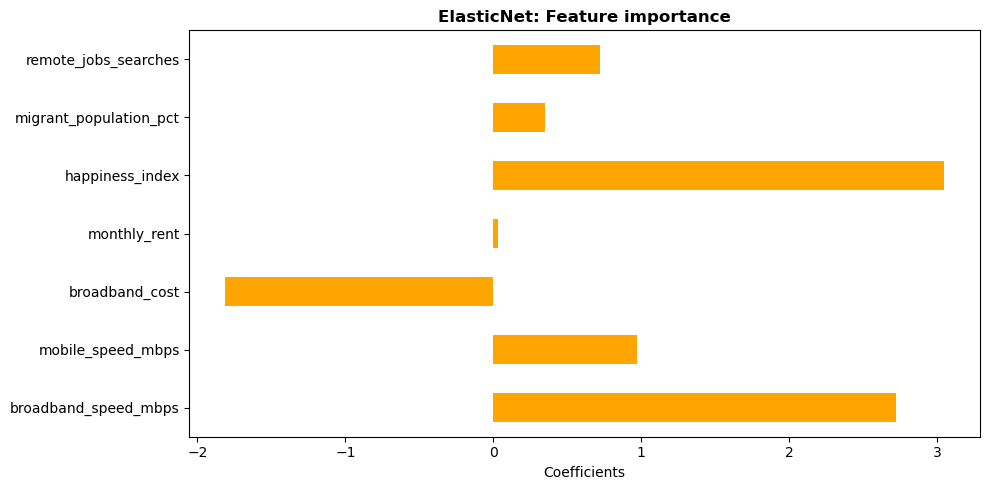

In [ ]:
fi = pd.DataFrame(
	elastic_net.coef_,
	index=elastic_net.feature_names_in_,
	columns=["feature importance"]
)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind="barh", ax=ax, color="orange", legend=False, edgecolor="none")
ax.set_title(
	"ElasticNet: Feature importance",
	fontweight="bold"
)
ax.set_xlabel("Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
results = cross_validate(
	estimator=elastic_net,
	X=df_train_scaled[features],
	y=df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = elastic_net.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.58
R2: 0.58

TEST
----------
RMSE: 6.4
R2: 0.69


El modelo tiene un buen rendimiento. No realiza overfitting y está generalizando correctamente.

#### `Fine Tuning`

In [ ]:
params = {
	"alpha": stats.loguniform(.0005, 5),
	"l1_ratio": stats.loguniform(.0005, 1)
}

randomized_search = RandomizedSearchCV(
	estimator=ElasticNet(max_iter=2000),
	param_distributions=params,
	n_iter=200,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring="neg_root_mean_squared_error",
	n_jobs=-1,
	random_state=42
)

randomized_search.fit(
	df_train_scaled[features],
	df_train_scaled[target]
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(max_iter=2000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': <scipy.stats....x7b7a6a9e04d0>, 'l1_ratio': <scipy.stats....x7b7a6a7a8140>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`

Revisamos los mejores parámetros

In [ ]:
best_params = randomized_search.best_params_
best_params

{'alpha': np.float64(0.1332558374527675),
 'l1_ratio': np.float64(0.0005362036273375518)}

In [28]:
elastic_net = ElasticNet(
	alpha=np.float64(0.1332558374527675),
	l1_ratio=np.float64(0.0005362036273375518),
	max_iter=2000
)
elastic_net.fit(df_train_scaled[features], df_train_scaled[target])

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",np.float64(0.1332558374527675)
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",np.float64(0....2036273375518)
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",2000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [29]:
results = cross_validate(
	elastic_net,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = elastic_net.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 4.8
R2: 0.67

TEST
----------
RMSE: 4.94
R2: 0.81


Hemos logrado bajal el error con `RandomizedSearch` y el modelo sigue generalizando correctamente.

### `RandomForestRegressor`

In [ ]:
random_forest = RandomForestRegressor(n_jobs=1, random_state=42)
random_forest.fit(df_train_scaled[features], df_train_scaled[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### `Feature Importance`

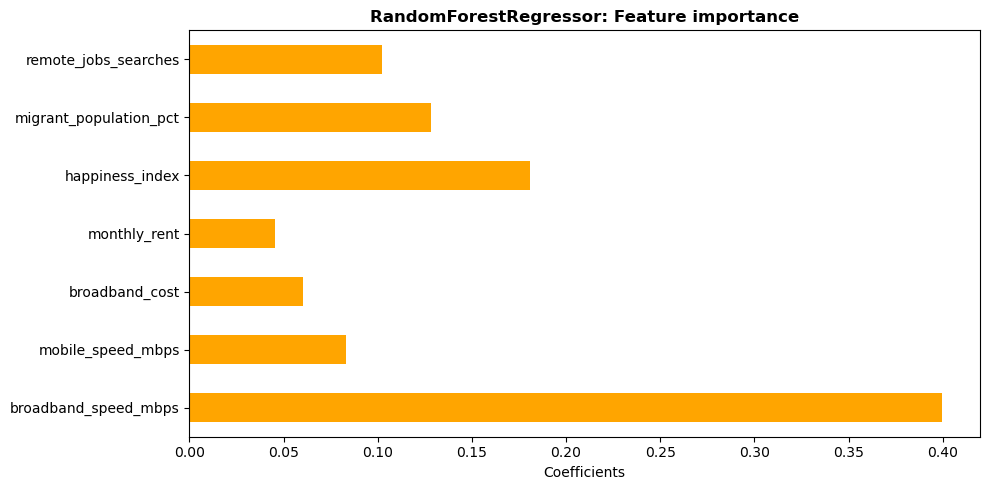

In [ ]:
fi = pd.DataFrame(
	random_forest.feature_importances_,
	index=random_forest.feature_names_in_,
	columns=["feature importance"]
)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind="barh", ax=ax, color="orange", legend=False, edgecolor="none")
ax.set_title(
	"RandomForestRegressor: Feature importance",
	fontweight="bold"
)
ax.set_xlabel("Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
results = cross_validate(
	random_forest,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.28
R2: 0.61

TEST
----------
RMSE: 5.76
R2: 0.75


#### `Fine Tuning`

In [ ]:
params = {
	"n_estimators": [100, 300, 500],
	"max_depth": [None, 5, 10, 20],
	"min_samples_split": [2, 5, 10],
	"min_samples_leaf": [1, 2, 4],
	"max_features": ["sqrt", "log2", 0.5],
	"bootstrap": [True]
}

grid_search = GridSearchCV(
	estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
	param_grid=params,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring="neg_root_mean_squared_error",
	n_jobs=-1
)
grid_search.fit(df_train_scaled[features], df_train_scaled[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messag

Revisamos los mejores hiperparámetros de nuestro modelo.

In [ ]:
best_params = grid_search.best_params_
best_params

{'bootstrap': True,
 'max_depth': 10,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500}

In [ ]:
random_forest = RandomForestRegressor(
	**best_params,
	n_jobs=-1,
	random_state=42
)
random_forest.fit(df_train_scaled[features], df_train_scaled[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
data = standard_scaler.fit_transform(df_train_scaled[features])
df_train_scaled[features] = data

data = standard_scaler.fit_transform(df_test_scaled[features])
df_test_scaled[features] = data

In [ ]:
results = cross_validate(
	random_forest,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = random_forest.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.15
R2: 0.63

TEST
----------
RMSE: 6.47
R2: 0.68


### `XGBoost`

In [27]:
from xgboost import XGBRegressor

In [28]:
xgboost = XGBRegressor(
	objective="reg:squarederror",
	n_jobs=-1,
	random_state=42
)
xgboost.fit(df_train_scaled[features], df_train_scaled[target])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

#### `Feature Importance`

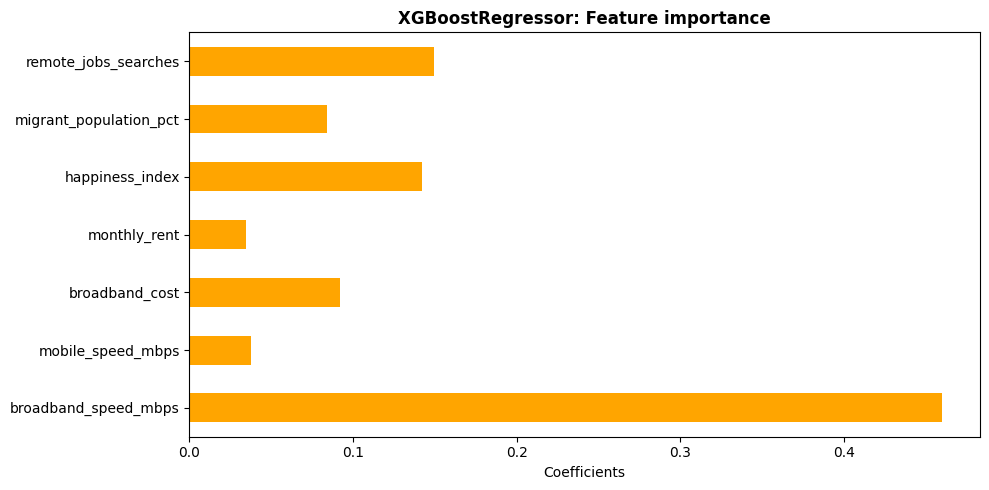

In [29]:
fi = pd.DataFrame(
	xgboost.feature_importances_,
	index=xgboost.feature_names_in_,
	columns=["feature importance"]
)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind="barh", ax=ax, color="orange", legend=False, edgecolor="none")
ax.set_title(
	"XGBoostRegressor: Feature importance",
	fontweight="bold"
)
ax.set_xlabel("Coefficients")
plt.tight_layout()
plt.show()

In [31]:
results = cross_validate(
	xgboost,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = xgboost.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.97
R2: 0.49

TEST
----------
RMSE: 6.25
R2: 0.7


#### `Fine Tuning`

In [ ]:
params = {
	"n_estimators": [400, 800, 1200],
	"learning_rate": [0.01, 0.03, 0.05, 0.1],
	"max_depth": [2, 3, 4, 6],
	"min_child_weight": [1, 3, 5],
	"subsample": [0.7, 0.85, 1.0],
	"colsample_bytree": [0.7, 0.85, 1.0],
	"gamma": [0, 0.05, 0.1],
	"reg_alpha": [0.0, 0.1, 1.0],
	"reg_lambda": [1.0, 3.0, 10.0],
}

grid_search = GridSearchCV(
	XGBRegressor(objective="reg:squarederror", n_jobs=-1, random_state=42),
	param_grid=params,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring="neg_root_mean_squared_error",
	n_jobs=-1
)
grid_search.fit(df_train_scaled[features], df_train_scaled[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.85, ...], 'gamma': [0, 0.05, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more m

In [ ]:
best_params = grid_search.best_params_
best_params

{'colsample_bytree': 1.0,
 'gamma': 0.05,
 'learning_rate': 0.01,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 1200,
 'reg_alpha': 0.0,
 'reg_lambda': 1.0,
 'subsample': 1.0}

In [35]:
xgboost = XGBRegressor(
    colsample_by_tree=1,
    gamma=.05,
    max_depth=4,
    min_child_weight=5,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=1,
    subsample=1,
	objective="reg:squarederror",
	n_jobs=-1,
	random_state=42
)
xgboost.fit(df_train_scaled[features], df_train_scaled[target])

XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_by_tree=1,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.05, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1200,
             n_jobs=-1, ...)

In [36]:
results = cross_validate(
	xgboost,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = xgboost.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.06
R2: 0.63

TEST
----------
RMSE: 5.63
R2: 0.76


### Conclusión


De los tres modelos seleccionados, con `ElasticNet` se consiguio el mejor resultado logrando generalización y performance en la métrica objetivo `RMSE`.

```python
TRAIN
----------
RMSE: 4.8
R2: 0.67

TEST
----------
RMSE: 4.94
R2: 0.81
```

In [30]:
joblib.dump(elastic_net, "../models/elastic_net.joblib")

['../models/elastic_net.joblib']

### Miscellaneous

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
target = ["digital_nomad_score"] # Elegimos el target

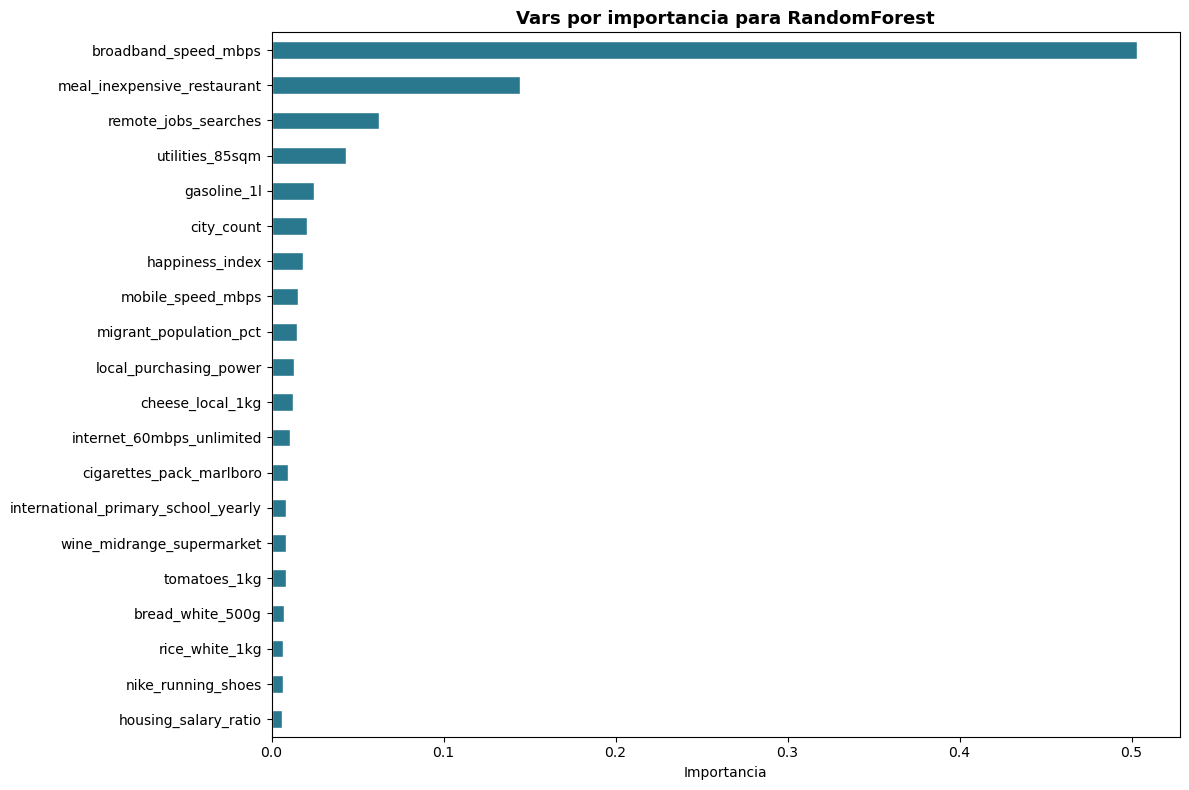

In [ ]:
# Usamos un modelo RandomForest para elegir variables candidatas finales para el modelo

X_temp = df_regression[feature_candidates_reduced].fillna(0)
y_temp = df_regression[target]

rf_selector = RandomForestRegressor(
	n_estimators=200,
	random_state=42,
	max_depth=4
)
rf_selector.fit(X_temp, y_temp)

importance = pd.Series(
	rf_selector.feature_importances_,
	index=feature_candidates_reduced
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
importance.head(20).sort_values().plot(
	kind="barh",
	ax=ax,
	color="#2A788E",
	edgecolor="white"
)
ax.set_title("Vars por importancia para RandomForest", fontweight="bold", fontsize=13)
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

#### Train-Test Split

In [ ]:
num_features = 12
selected_features = importance.head(num_features).index.tolist()
print(selected_features)

['broadband_speed_mbps', 'meal_inexpensive_restaurant', 'remote_jobs_searches', 'utilities_85sqm', 'gasoline_1l', 'city_count', 'happiness_index', 'mobile_speed_mbps', 'migrant_population_pct', 'local_purchasing_power', 'cheese_local_1kg', 'internet_60mbps_unlimited']


In [ ]:
# Split entre train y test

X = df_regression[selected_features].fillna(0)
y = df_regression["digital_nomad_score"]

X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42
)

print(f"Train: {X_train.shape[0]} países ({X_train.shape[0]/len(X):.0%})")
print(f"Test: {X_test.shape[0]} países ({X_test.shape[0]/len(X):.0%})")

Train: 64 países (79%)
Test: 17 países (21%)


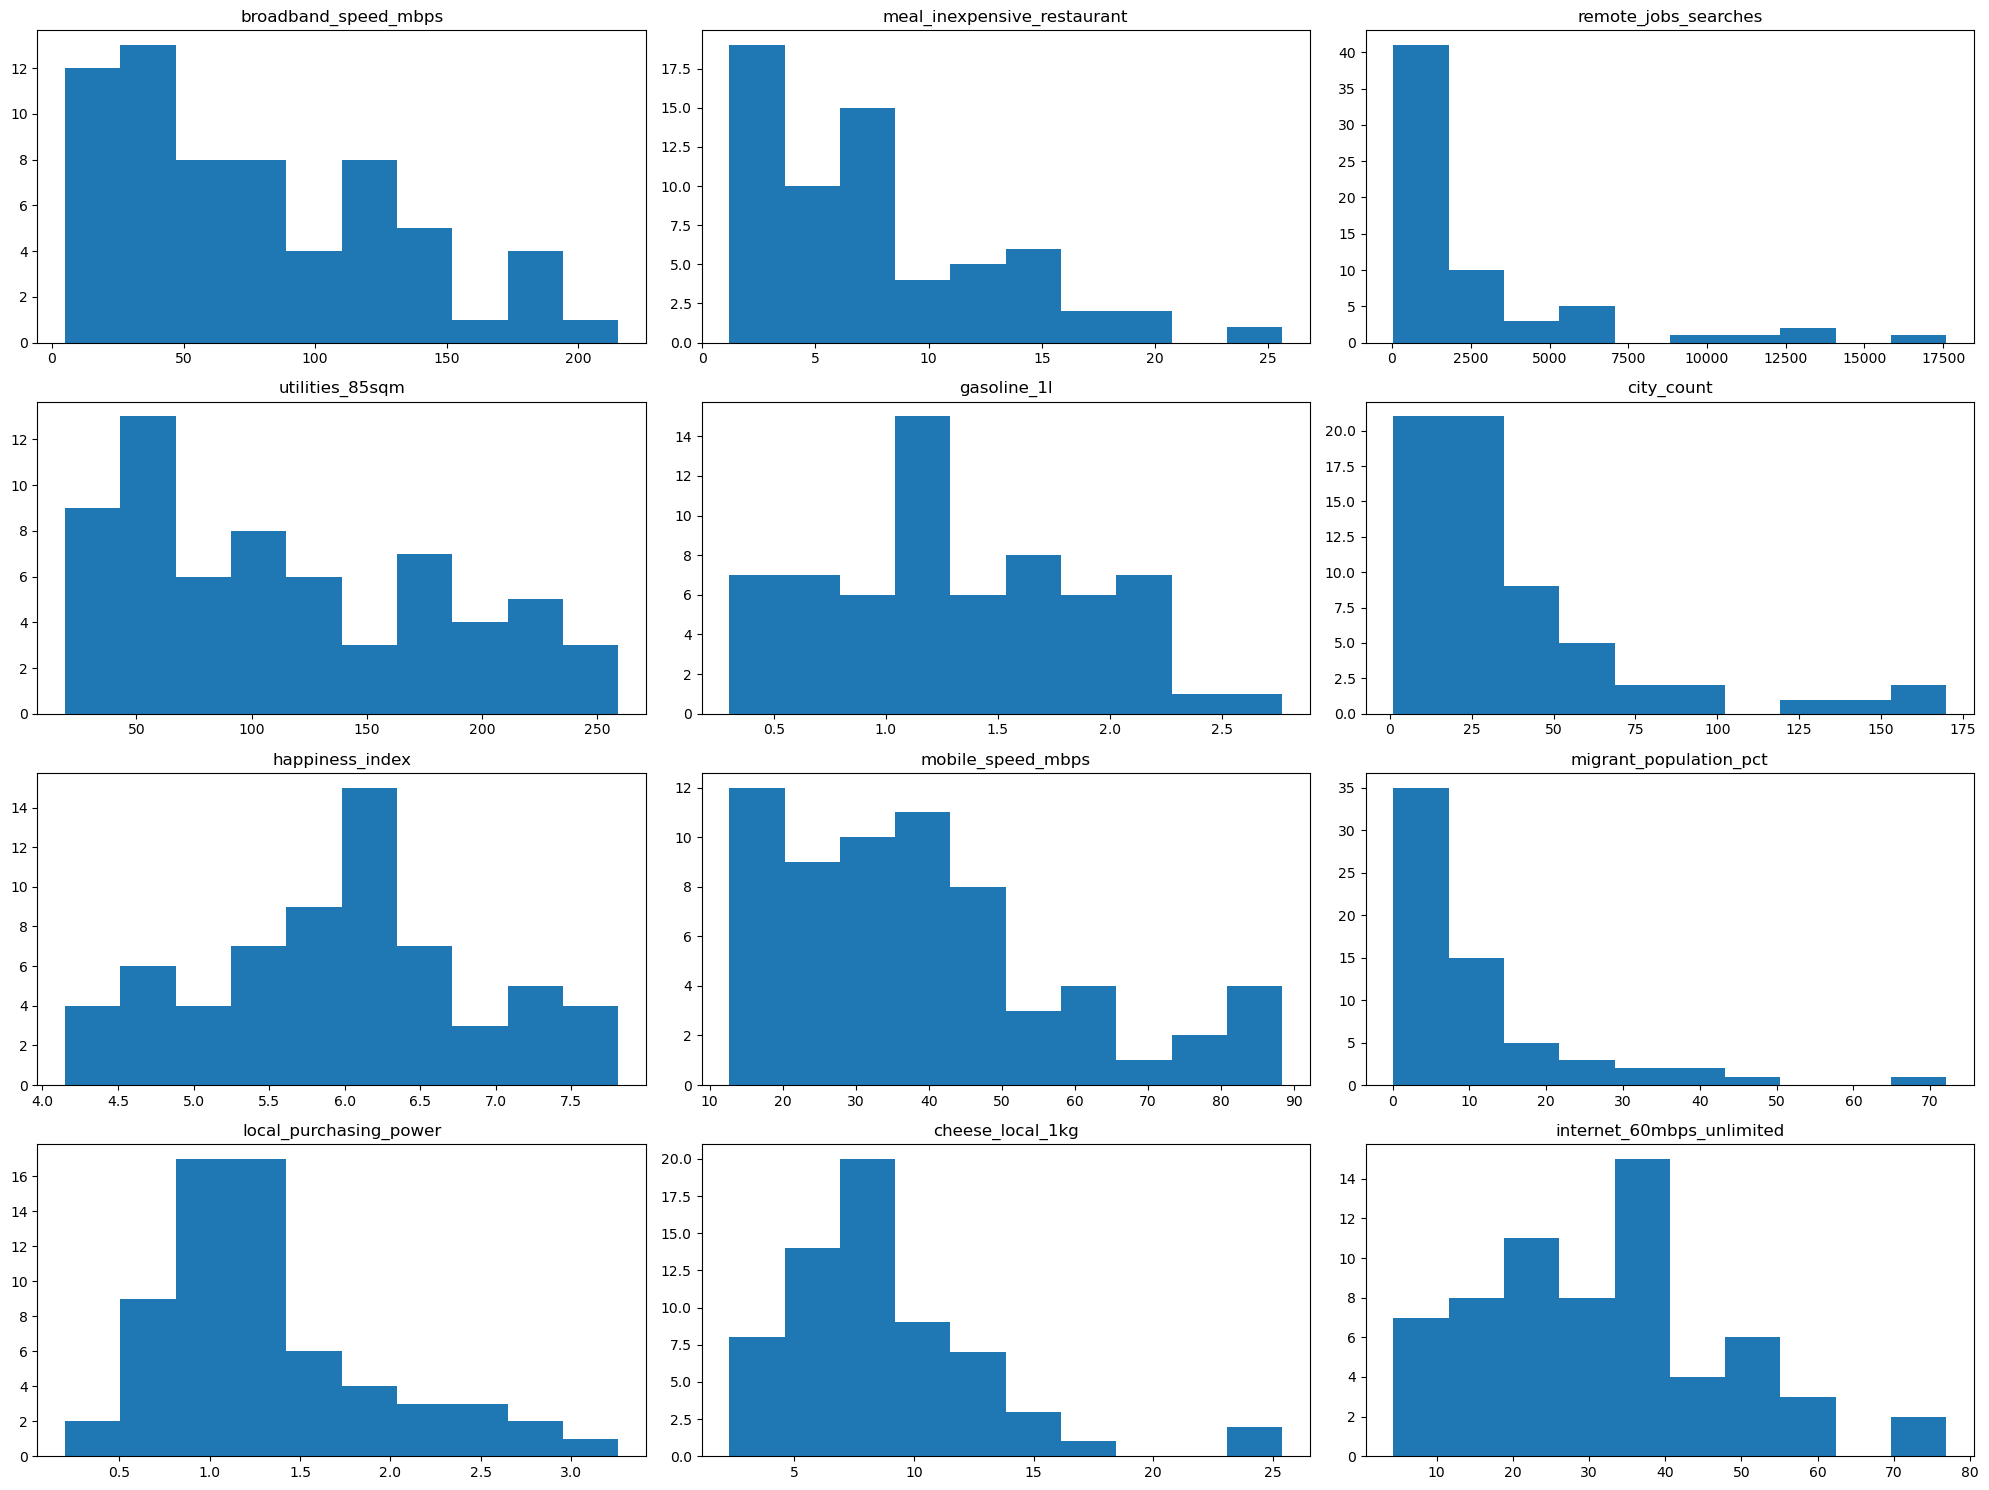

In [ ]:
# Comprobamos si las variables van a necesitar escalado debido a la diferencia de magnitudes

fig, ax = plt.subplots(figsize=(20, 15), layout="constrained")
X_train.hist(grid=False, zorder=2, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# El orden de magnitud nos obliga a escalar las variables

scaler_regression = StandardScaler()
X_train_scaled = scaler_regression.fit_transform(X_train)
X_test_scaled = scaler_regression.transform(X_test)

#### LinearRegression

In [ ]:
# Usamos un modelo de regresión lineal como baseline

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Hacemos la predicción con los datos de test

y_pred_baseline_train = baseline_model.predict(X_train_scaled)
y_pred_baseline_test = baseline_model.predict(X_test_scaled)

In [ ]:
# Sacamos las métricas principales del modelo baseline de regresión lineal

print("Modelo de regresión lineal:")
print(f"\tTrain R²:  {r2_score(y_train, y_pred_baseline_train):.4f}")
print(f"\tTest R²:   {r2_score(y_test, y_pred_baseline_test):.4f}")
print(f"\tTest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_baseline_test)):.2f}")
print(f"\tTest MAE:  {mean_absolute_error(y_test, y_pred_baseline_test):.2f}")

Modelo de regresión lineal:
	Train R²:  0.8179
	Test R²:   0.7364
	Test RMSE: 5.95
	Test MAE:  4.43


#### Otros modelos: `Ridge`, `Lasso`, `ElasticNet`, `RandomForest`, `GradientBoosting`, `SVR`

In [ ]:
# Validación cruzada con otros modelos de regresión para ponerlos a competir

models = {
	"Linear Regression": LinearRegression(),
	"Ridge": Ridge(random_state=42),
	"Lasso": Lasso(random_state=42),
	"ElasticNet": ElasticNet(random_state=42),
	"Random Forest": RandomForestRegressor(random_state=42),
	"Gradient Boosting": GradientBoostingRegressor(random_state=42),
	"SVR": SVR()
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
	scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="r2")
	results.append({
		"Modelo": name,
		"CV R² (media)": scores.mean(),
		"CV R² (std)": scores.std()
	})

df_results = pd.DataFrame(results).sort_values("CV R² (media)", ascending=False)

In [ ]:
print("Comparativa de modelos (Cross-Validation k=5)")
display(df_results.reset_index(drop=True))

Comparativa de modelos (Cross-Validation k=5)


,Modelo,CV R² (media),CV R² (std)
0,Ridge,0.707924,0.059762
1,Linear Regression,0.699065,0.065025
2,Random Forest,0.688866,0.072172
3,Lasso,0.687007,0.087315
4,ElasticNet,0.681043,0.060379
5,Gradient Boosting,0.676848,0.096178
6,SVR,0.246574,0.174168


- En principio el modelo ganador sería Ridge.
- Lo seguirían los modelos de regresión lineal (baseline) y Random Forest.

In [ ]:
# Vamos a ajustar los modelos de Ridge y Random Foreest con hiperparámetros
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parametros_ridge = {"alpha": [0.1, 1.0, 10.0, 100.0]}

grid_ridge = GridSearchCV(
	ridge,
	parametros_ridge,
	cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
grid_ridge.fit(X_train_scaled, y_train)

print(f"Mejor alpha para Ridge: {grid_ridge.best_params_}")
print(f"Mejor CV R²: {grid_ridge.best_score_:.4f}")

Mejor alpha para Ridge: {'alpha': 10.0}
Mejor CV R²: 0.7226


Al ajustar Ridge con hiperparámetros hemos mejorado algo la métrica.

In [ ]:
rf = RandomForestRegressor(random_state=42)
parametros_rf = {
	"n_estimators": [50, 100, 200],
	"max_depth": [None, 10, 20],
	"min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
	rf,
	parametros_rf,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor CV R²: {grid_rf.best_score_:.4f}")

Mejores parámetros RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Mejor CV R²: 0.6897


Random Forest no mejora en exceso.

In [ ]:
# Probamos a ajustar Lasso
lasso = Lasso(random_state=42)

parametros_lasso = {
	"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_lasso = GridSearchCV(
	lasso,
	parametros_lasso,
	cv=5,
	scoring="r2"
)


grid_lasso.fit(X_train_scaled, y_train)

print(f"Mejor valor de alpha para Lasso: {grid_lasso.best_params_}")
print(f"Mejor CV R²: {grid_lasso.best_score_:.4f}")

Mejor valor de alpha para Lasso: {'alpha': 0.1}
Mejor CV R²: 0.7076


Lasso si mejora con el ajuste con hiperparámetros. Aunque por debajo de Ridge

#### Probamos el modelo ganador contra test

In [ ]:
# Predicción contra test
y_pred = grid_ridge.predict(X_test_scaled)

In [ ]:
# Comparación de métricas

# Calculamos R2 (proporción de varianza explicada)
r2_test = r2_score(y_test, y_pred)

# Calculamos el error cuadrático medio (MSE) y su raíz (RMSE)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

# Calculamos el error absoluto medio (MAE)
mae_test = mean_absolute_error(y_test, y_pred)

print(f"R² en Test: {r2_test:.4f}")
print(f"RMSE en Test: {rmse_test:.4f}")
print(f"MAE en Test: {mae_test:.4f}")

R² en Test: 0.8228
RMSE en Test: 4.8789
MAE en Test: 4.0444


In [ ]:
#ses peor predichos (mayores errores)
test_countries = df_regression.iloc[X_test.index][["country_name"]].copy()
test_countries["real"] = y_test.values
test_countries["pre Paídiccion"] = y_pred
test_countries["error_abs"] = np.abs(y_test.values - y_pred)
test_countries = test_countries.sort_values("error_abs", ascending=False)

print("Top 5 países con mayor error de predicción")
display(test_countries.head(5).reset_index(drop=True))

print("Predicciones completas en test")
display(test_countries.sort_values("real", ascending=False).reset_index(drop=True))

Top 5 países con mayor error de predicción


,country_name,real,prediccion,error_abs
0,Canada,74.35,84.684569,10.334569
1,Ghana,30.36,40.287718,9.927718
2,Ireland,53.15,59.065084,5.915084
3,Albania,38.97,44.361495,5.391495
4,El Salvador,36.60,41.886470,5.286470


Predicciones completas en test


,country_name,real,prediccion,error_abs
0,Canada,74.35,84.684569,10.334569
1,Sweden,61.54,60.697485,0.842515
2,Denmark,61.49,63.819978,2.329978
3,Hungary,59.12,55.999661,3.120339
4,Luxembourg,59.06,56.216605,2.843395
5,Singapore,58.76,60.721020,1.961020
6,Austria,57.31,55.528454,1.781546
7,Slovakia,54.39,52.622158,1.767842
8,Ireland,53.15,59.065084,5.915084
9,Mexico,52.08,50.118733,1.961267


#### Guardamos el modelo de regresión

In [ ]:
best_model = grid_ridge.best_estimator_

joblib.dump(best_model, "../models/regressor_nomad_score.joblib")
joblib.dump(scaler_regression, "../models/scaler_regression.joblib")

['../models/scaler_regression.joblib']